### 로지스틱 회귀   
: 선형방정식을 이용해서 회귀란 단어가 있지만 실제적으로 분류에 대한 확률을 계산하는 모델   
ex) iris에서 무슨 꽃이 될 확률이 몇 %이다

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
fish = pd.read_csv("../Data/fishes.csv")
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [4]:
fish.shape

(159, 6)

In [5]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


In [7]:
# Target으로 사용될 Species의 종류
fish['Species'].value_counts()
# 로지스틱 회귀는 확률값을 구하는거라 타겟비율이 필요가 없다.

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

### Feature와 Target DATA 정하기

In [13]:
fish.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


In [8]:
# Feature
fish_input = fish.iloc[:,1:].to_numpy()
fish_input[:5]

# numpy array는 모두 float형태이다.


array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [9]:
# Target
fish_target = fish['Species'].to_numpy()
fish_target[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

### Train과 Test

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
train_input, test_input, train_target, test_target = \
  train_test_split(
    fish_input,
    fish_target,
    random_state=42,
  )

In [12]:
train_input[:5]

array([[720.    ,  35.    ,  40.6   ,  16.3618,   6.09  ],
       [500.    ,  45.    ,  48.    ,   6.96  ,   4.896 ],
       [  7.5   ,  10.5   ,  11.6   ,   1.972 ,   1.16  ],
       [110.    ,  22.    ,  23.5   ,   5.5225,   3.995 ],
       [140.    ,  20.7   ,  23.2   ,   8.5376,   3.2944]])

### 표준화 시키기
: 각 컬럼별 데이터의 크기가 차이가 많이 나는 경우

In [15]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

train_scaled[:5]

array([[ 0.91965782,  0.60943175,  0.81041221,  1.85194896,  1.00075672],
       [ 0.30041219,  1.54653445,  1.45316551, -0.46981663,  0.27291745],
       [-1.0858536 , -1.68646987, -1.70848587, -1.70159849, -2.0044758 ],
       [-0.79734143, -0.60880176, -0.67486907, -0.82480589, -0.27631471],
       [-0.71289885, -0.73062511, -0.70092664, -0.0802298 , -0.7033869 ]])

In [16]:
test_scaled[:5]

array([[-0.88741352, -0.91804565, -1.03098914, -0.90464451, -0.80762518],
       [-1.06924656, -1.50842035, -1.54345461, -1.58849582, -1.93803151],
       [-0.54401367,  0.35641402,  0.30663259, -0.8135697 , -0.65388895],
       [-0.34698097, -0.23396068, -0.22320459, -0.11905019, -0.12233464],
       [-0.68475132, -0.51509149, -0.58801052, -0.8998784 , -0.50124996]])

---
### kNN을 이용한 확률 예측

In [17]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print("train :", kn.score(train_scaled, train_target))
print("test  :", kn.score(test_scaled, test_target))

train : 0.8907563025210085
test  : 0.85


In [18]:
# kn의 분류 정보
kn.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [19]:
kn.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype=object)

In [23]:
# test data의 확률 예측값 보기
import numpy as np

prob = kn.predict_proba(test_scaled[:5]) # 확률값을 예측해봐라
np.round(prob, decimals=4)
 # 'Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'

array([[0.    , 0.    , 1.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 1.    , 0.    ],
       [0.    , 0.    , 0.    , 1.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ]])

---
#### 로지스틱 회귀를 이용한 확률 예측
- 데이터의 각 컬럼을 새로운 변수로 사용하는 다중회귀를 이용한 확률
- 회귀식을 사용해서 로지스틱 회귀라고 하나 실질적으로는 확률을 예측하는 모델
- 선형회귀식에서 출발하였고 딥러닝 모델의 기반임.

기본적으로 위의 데이터를 보면  
z = a무게 + b길이 + c대각선 + d높이 + e두께 + f 로 구성된다.  
위의 식으로 z를 구하면 -무한대 ~ +무한대의 범위로 결과 값이 출력된다.  
이를 해결하는 방법으로 Sigmoid함수를 사용한다.  
Sigmoid함수는 결과값이 0~1 사이의 수만 출력하므로, 0.5를 기준으로 양성클래스와 음성클래스로 분류한다.   
로지스틱 회귀를 사용할 경우에는 Sigmoid함수를 로지스틱 함수라고 표현한다.   

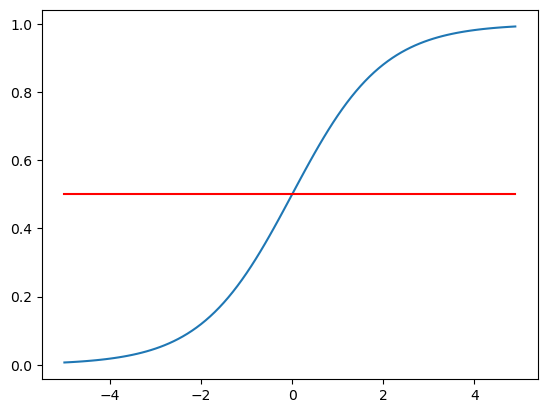

In [31]:
# Sigmoid Graph 출력해보기

import matplotlib.pyplot as plt

z = np.arange(-5, 5, 0.1)
y = np.full((100,1),0.5) # row 100개를 0.5로 채워라. 0.5 선을 그리기 위해


phi = 1 / (1 + np.exp(-z)) # Sigmoid 공식

plt.plot(z,phi)

plt.plot(z,y,c='red')

plt.show()

> 실질적으로 x의 값이 0 이상이면 양성클래스, 0이하이면 음성클래스로 분류하여 이를     
이용하는 것이 predict함수 이며    
각각의 확률 수치를 알아보는 것이 predict_proba 함수이다.   

---
### 로지스틱 회귀로 이진 분류 수행하기

In [32]:
# 2종류의 데이터 발췌
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]
print(train_bream_smelt[:5])
print(target_bream_smelt[:5])

[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [ 0.63818253  0.56257661  0.73223951  1.64473401  0.50705737]
 [ 0.30041219  0.23459067  0.42823457  1.36042157  0.22329758]
 [ 0.9027693   0.70314202  0.88858491  1.89027545  0.85537174]]
['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [33]:
# 로지스틱 회귀 실행하기
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

LogisticRegression()

In [34]:
lr.predict(train_bream_smelt[:5])

array(['Bream', 'Smelt', 'Bream', 'Bream', 'Bream'], dtype=object)

In [35]:
# 확률 분포 확인
lr.predict_proba(train_bream_smelt[:5])

array([[0.99760007, 0.00239993],
       [0.02737325, 0.97262675],
       [0.99486386, 0.00513614],
       [0.98585047, 0.01414953],
       [0.99767419, 0.00232581]])

In [36]:
lr.classes_

array(['Bream', 'Smelt'], dtype=object)

In [37]:
# 회귀식의 기울기(가중치)
print(lr.coef_, lr.intercept_)

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]


In [38]:
# 다중식으로 계산
decision = lr.decision_function(train_bream_smelt[:5])
print(decision)

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [39]:
# Sigmoid 함수에 대입하여 확률 값을 구한다.
from scipy.special import expit
print(expit(decision))
# 1번확률값이 나온다. 0확률값은 1에서 빼서 구한다.

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


> predict_proba로 에측한 확률분포와 비교하면 1번 분류와 동일하다는 것을 알 수 있다.   
0번의 확률은 1-1번 확률로 계산된다.   

> 검증완료

---
#### 로지스틱 회귀로 다중 분류 수행하기

In [103]:
lr = LogisticRegression(C=20, max_iter=1000) # C는 규제 - 20은 규제가 약함, max_iter는 epoch(반복횟수)
lr.fit(train_scaled, train_target)

print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))


0.9327731092436975
0.925


> C: 규제(릿지규제)이며 기본은 1. 적은수가 강한 규제   
max_itre : 반복횟수, 모델의 정확성을 유지하기 위해 반복작업을 실시. 기본은 100   

In [50]:
# 분류
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [43]:
# test data로 예측
lr.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Roach', 'Perch'], dtype=object)

In [51]:
prob = lr.predict_proba(test_scaled[:5])
np.round(prob, decimals=3)

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])

In [52]:
# 사용된 다중 공식
print(lr.coef_, lr.intercept_)

[[-1.50605456 -1.03747913  2.60919713  7.69422741 -1.18603342]
 [ 0.19200046 -1.99988812 -3.79617724  6.5031264  -2.00022753]
 [ 3.55793539  6.36988929 -8.52233733 -5.75397233  3.79233438]
 [-0.11453309  3.61060121  3.94464503 -3.62243904 -1.75981679]
 [-1.40843718 -6.09242191  5.28629634 -0.8669657   1.84518456]
 [-1.33419947  1.48153392  1.38217547 -5.6602348  -4.39228964]
 [ 0.61328845 -2.33223526 -0.90379939  1.70625807  3.70084846]] [-0.10345047 -0.27281218  3.24444852 -0.17565069  2.64960025 -6.72042849
  1.37829306]


---
### 확률 분포 검증

In [55]:
# 다중식으로 계산
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=2))

[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6.24   3.17   6.48   2.36   2.43  -3.87]
 [ -0.69   0.45   2.64  -1.21   3.26  -5.7    1.26]
 [ -6.4   -1.99   5.82  -0.13   3.5   -0.09  -0.7 ]]


> 계산할 항목이 여러개이므로 Sigmoid를 사용하면 각자의 값이 생성되어 확률의 합이 1이넘는 경우가 발생한다.   
다중항목인 경우에는 Softmax를 사용한다.  

In [56]:
from scipy.special import softmax

proba = softmax(decision, axis=1)
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


---
### Perch와 Whitefish 이중분류

In [86]:
# 2종류의 데이터 발췌
perch_whitefish_indexes = (train_target == 'Perch') | (train_target == 'Whitefish')
train_perch_whitefish = train_scaled[perch_whitefish_indexes]
target_perch_whitefish = train_target[perch_whitefish_indexes]
print(train_perch_whitefish[:5])
print(target_perch_whitefish[:5])

[[-0.79734143 -0.60880176 -0.67486907 -0.82480589 -0.27631471]
 [-0.79734143 -0.70251203 -0.76172762 -0.78282455 -0.54453018]
 [-0.74104638 -0.67439895 -0.73567006 -0.61205928 -0.55733138]
 [-0.86771025 -0.7962223  -0.89201546 -0.93358694 -1.02183182]
 [ 0.82114147  0.74999715  0.67143852  0.4984706   1.47257213]]
['Perch' 'Perch' 'Perch' 'Perch' 'Perch']


In [101]:
# 로지스틱 회귀 실행하기
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=30, max_iter=1000)
lr.fit(train_perch_whitefish, target_perch_whitefish)

print(lr.score(train_perch_whitefish, target_perch_whitefish))
print(lr.score(test_scaled, test_target))

0.9574468085106383
0.3


In [95]:
lr.predict(train_perch_whitefish)

array(['Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch',
       'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch',
       'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch',
       'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch',
       'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch',
       'Whitefish', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch', 'Perch',
       'Perch', 'Perch', 'Perch', 'Perch', 'Perch'], dtype=object)

In [100]:
# 확률 분포 확인
lr.predict_proba(train_perch_whitefish)

array([[9.93213620e-01, 6.78637990e-03],
       [9.84770861e-01, 1.52291393e-02],
       [9.45041623e-01, 5.49583766e-02],
       [9.92571954e-01, 7.42804575e-03],
       [9.02563090e-01, 9.74369103e-02],
       [8.41272744e-01, 1.58727256e-01],
       [9.67253942e-01, 3.27460575e-02],
       [9.86148067e-01, 1.38519334e-02],
       [9.80773020e-01, 1.92269800e-02],
       [9.87824129e-01, 1.21758706e-02],
       [8.83463349e-01, 1.16536651e-01],
       [9.86605021e-01, 1.33949791e-02],
       [8.42549478e-01, 1.57450522e-01],
       [9.53190009e-01, 4.68099910e-02],
       [9.65798619e-01, 3.42013811e-02],
       [9.88982825e-01, 1.10171754e-02],
       [9.01975589e-01, 9.80244106e-02],
       [9.96914428e-01, 3.08557210e-03],
       [9.89140291e-01, 1.08597093e-02],
       [9.26711195e-01, 7.32888050e-02],
       [9.80556196e-01, 1.94438044e-02],
       [9.88915229e-01, 1.10847706e-02],
       [9.21032809e-01, 7.89671910e-02],
       [9.74987036e-01, 2.50129637e-02],
       [9.908705

In [97]:
lr.classes_

array(['Perch', 'Whitefish'], dtype=object)

In [83]:
# 회귀식의 기울기(가중치)
print(lr.coef_, lr.intercept_)

[[-2.08641201 -3.35281058  0.57232151  7.19377013  0.01339877]] [-1.85460322]


In [98]:
# 다중식으로 계산
decision = lr.decision_function(train_perch_whitefish[:5])
print(decision)

[-4.98602812 -4.16919834 -2.84465286 -4.89503671 -2.2260335 ]


In [99]:
# Sigmoid 함수에 대입하여 확률 값을 구한다.
from scipy.special import expit
print(expit(decision))
# 1번확률값이 나온다. 0확률값은 1에서 빼서 구한다.

[0.00678638 0.01522914 0.05495838 0.00742805 0.09743691]
